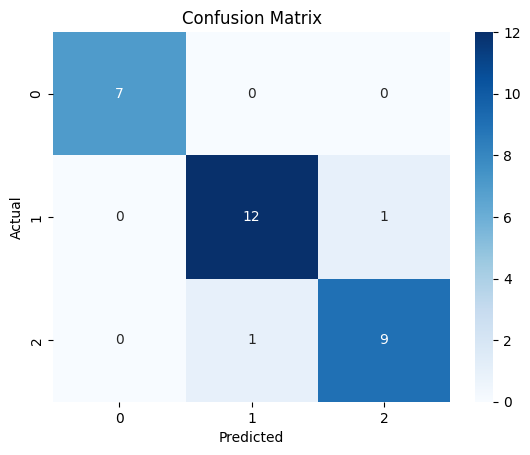

Accuracy: 0.9333333333333333
+---+---+----+----------+----------+
| id|  x|   y|  features|prediction|
+---+---+----+----------+----------+
|  1|1.0| 2.0| [1.0,2.0]|         1|
|  2|1.5| 1.8| [1.5,1.8]|         1|
|  3|5.0| 8.0| [5.0,8.0]|         0|
|  4|8.0| 8.0| [8.0,8.0]|         0|
|  5|1.0| 0.6| [1.0,0.6]|         1|
|  6|9.0|11.0|[9.0,11.0]|         0|
+---+---+----+----------+----------+



In [1]:
# ---- PART A: Logistic Regression + Confusion Matrix ----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))


# ---- PART B: K-Means Clustering using PySpark ----

from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler

spark = SparkSession.builder.appName("KMeans Example").getOrCreate()

data = [
    (1, 1.0, 2.0),
    (2, 1.5, 1.8),
    (3, 5.0, 8.0),
    (4, 8.0, 8.0),
    (5, 1.0, 0.6),
    (6, 9.0, 11.0)
]

columns = ["id", "x", "y"]
df = spark.createDataFrame(data, columns)

assembler = VectorAssembler(inputCols=["x", "y"], outputCol="features")
data_final = assembler.transform(df)

kmeans = KMeans(k=2, seed=1)
model = kmeans.fit(data_final)

result = model.transform(data_final)
result.show()

spark.stop()